Django REST Framework (DRF) is a powerful toolkit for building Web APIs in Django. It simplifies the process of creating RESTful web services with Django by providing a set of ready-to-use features such as serialization for ORM and non-ORM data sources, view classes for different kinds of APIs, and authentication policies. Let's discuss how it works and how this setup and how it has transitioned from using static data to fetching live data from OANDA.

First of all you must understand that Communication between client computers and web servers is done by sending HTTP Requests and receiving HTTP Responses. This is how the World Wide Web Communication works.

### Basic Workflow with Django REST Framework:

1. **Request Handling**: In a typical Django application (including those using DRF), a client (like your Vue frontend) makes an HTTP request to a URL configured in your Django project. This request is handled by a view.

2. **Views**: DRF provides several types of views (like `APIView`, `ViewSet`) which help in handling different HTTP methods (GET, POST, PUT, DELETE). These views use serializers to parse and validate incoming data and to serialize outgoing data.

3. **Serializers**: These are responsible for converting complex data types (like Django models or other Python data structures) into JSON, XML, or other content types. Serializers also handle deserialization, turning incoming data into Python data types.

4. **Response**: The view processes the data using business logic, fetching or updating data as required, and returns an HTTP response, typically as JSON data.

### Transition from Static Data to Live Data with OANDA:

#### Using Static Data
Initially, you might have been using Django models or static files to serve data. Here, the data flow would be:
- **Frontend makes a request**: Vue app sends a request to a Django endpoint.
- **Django retrieves static data**: Your Django view retrieves data from the database or a static file, which is predefined and doesn't change unless you manually update it.
- **Data returned to frontend**: The data is serialized into JSON and sent back to the Vue app.

#### Switching to Live Data from OANDA
Now, with OANDA, instead of relying on static or database-stored data, you fetch live data from an external API. Here’s how this modifies your workflow:
- **Frontend makes a request**: Vue app sends a request to your Django server as before.
- **Django makes an API call**: Instead of fetching data from a local database or file, your Django view executes an API call to OANDA using the `requests` library. This happens inside the view each time a request is made, ensuring the data is up-to-date.
- **Processing API response**: The response from OANDA is received by Django, which then processes this data (if necessary) and uses serializers to convert the data into a suitable format for your frontend.
- **Data returned to frontend**: The serialized data is sent back as a response to the Vue app.

### Advantages of Live Data from OANDA
- **Real-time information**: You get the latest market data, which is crucial for applications dealing with financial information.
- **Dynamic response**: The data can change rapidly, and your application can now handle these changes in real-time, providing a more accurate and timely response to the end user.

### Considerations
- **Error Handling**: More robust error handling is necessary to manage potential issues with the OANDA API, such as network problems or API limits.
- **Caching**: Depending on the nature of the data and request frequency, you might want to implement caching strategies to reduce the number of API calls and speed up response times.
- **Security and API Rate Limits**: Securely handle API keys and be aware of any rate limits or costs associated with using the OANDA API.

This transition from static to live data fetching makes your application more complex but significantly more powerful and useful, especially in scenarios where up-to-date information is critical.

##### Questions
* **How would serialization and deserialization work if there was no DRF?**

- App (root component)
  |- Navbar
  |   |- LoginButton
  |   |- LogoutButton
  |- Dashboard
  |   |- ProfileSummary
  |   |- BalanceDisplay
  |- TradingView
  |   |- PriceStream (Real-time pricing)
  |   |- TradeForm
  |       |- CurrencySelector
  |       |- VolumeInput
  |   |- OpenTrades
  |       |- TradeItem
  |- HistoryView
  |   |- TradeHistoryList
  |       |- TradeHistoryItem
  |- AccountManagement
      |- UserDetailsForm
      |- PasswordChangeForm


In [2]:
!pip3 install requests


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip3 install --upgrade pip


In [16]:

API_KEY = "867f258a6a978d867493454cba2b27ff-97f17371b95cbe3171cf608c46a51c91"
ACCOUNT_ID = "101-004-29382789-001"

In [17]:
import requests
import json


url = 'https://stream-fxpractice.oanda.com/v3/accounts/101-004-29382789-001/pricing/stream?instruments=EUR_USD'
head = {'Content-type':"application/octet-stream",
        'Accept-Datetime-Format':"RFC3339",
        'Authorization': f"Bearer {API_KEY}"}


r = requests.get(url, headers=head, stream=True)
print(r)

for line in r.iter_lines():

    if line:
        decoded_line = line.decode('utf-8')
        print(json.loads(decoded_line))

<Response [200]>
{'type': 'PRICE', 'time': '2024-07-31T10:41:23.721628825Z', 'bids': [{'price': '1.08335', 'liquidity': 500000}, {'price': '1.08334', 'liquidity': 2500000}, {'price': '1.08333', 'liquidity': 2000000}, {'price': '1.08332', 'liquidity': 5000000}, {'price': '1.08329', 'liquidity': 10000000}, {'price': '1.08326', 'liquidity': 10000000}], 'asks': [{'price': '1.08342', 'liquidity': 500000}, {'price': '1.08343', 'liquidity': 500000}, {'price': '1.08344', 'liquidity': 2000000}, {'price': '1.08345', 'liquidity': 2000000}, {'price': '1.08346', 'liquidity': 5000000}, {'price': '1.08348', 'liquidity': 10000000}, {'price': '1.08351', 'liquidity': 10000000}], 'closeoutBid': '1.08326', 'closeoutAsk': '1.08351', 'status': 'tradeable', 'tradeable': True, 'instrument': 'EUR_USD'}
{'type': 'PRICE', 'time': '2024-07-31T10:41:26.802104247Z', 'bids': [{'price': '1.08334', 'liquidity': 500000}, {'price': '1.08333', 'liquidity': 2500000}, {'price': '1.08332', 'liquidity': 2000000}, {'price': '

KeyboardInterrupt: 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the data
data = pd.read_csv('trades_profit_loss.csv')
data.head()


,id,profile_id,entry_price,exit_price,volume,trade_type,profit_loss
0,2,1,1.3600,1.3586,10.0,sell,0.014
1,3,1,1.3057,1.3109,10.0,buy,0.052
2,4,1,1.3600,1.3592,10.0,sell,0.008
3,1156,1,189.8680,190.2500,0.0,buy,0.000
4,1152,1,1.3090,1.3122,0.0,buy,0.000


In [6]:
data.shape

(867, 7)

In [17]:
data.describe()

,id,profile_id,entry_price,exit_price,volume,profit_loss
count,867.000000,867.0,867.000000,867.000000,867.000000,867.000000
mean,1360.307958,1.0,82.691979,82.795368,3.418420,-0.137972
std,693.650827,0.0,84.424590,84.538843,4.753768,2.570418
min,1.000000,1.0,0.669800,0.670000,-0.500000,-8.685000
25%,772.000000,1.0,1.115000,1.110600,0.000000,-0.000091
50%,1321.000000,1.0,1.361300,1.361300,0.000000,0.000000
75%,1885.000000,1.0,146.294500,146.234000,10.000000,0.000064
max,3002.000000,1.0,191.687000,191.733500,10.000000,6.590000


In [10]:
# # Basic Profit/Loss Distribution Plot
# sns.histplot(data['profit_loss'], kde=True)
# plt.title('Distribution of Profit/Loss per Trade')
# plt.xlabel('Profit/Loss')
# plt.ylabel('Number of Trades')
# plt.show()

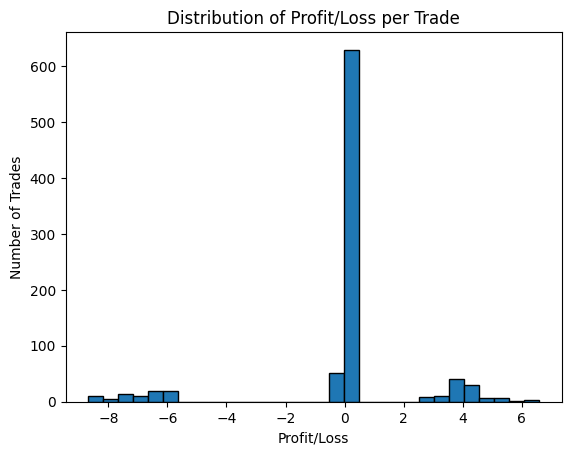

In [11]:
# Plot histogram using matplotlib
plt.hist(data['profit_loss'], bins=30, edgecolor='black')
plt.title('Distribution of Profit/Loss per Trade')
plt.xlabel('Profit/Loss')
plt.ylabel('Number of Trades')
plt.show()

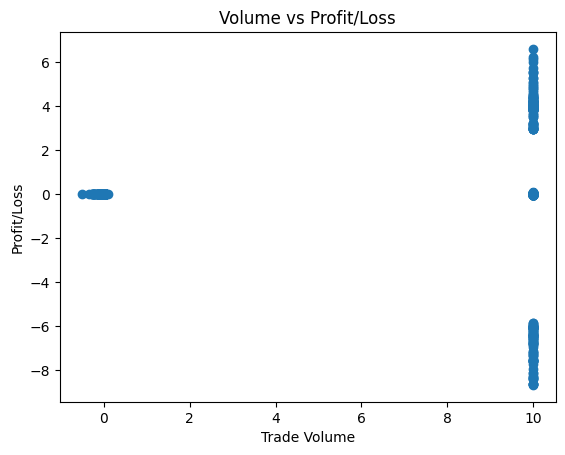

In [7]:
# Scatter Plot: Volume vs Profit/Loss
plt.scatter(data['volume'], data['profit_loss'])
plt.title('Volume vs Profit/Loss')
plt.xlabel('Trade Volume')
plt.ylabel('Profit/Loss')
plt.show()



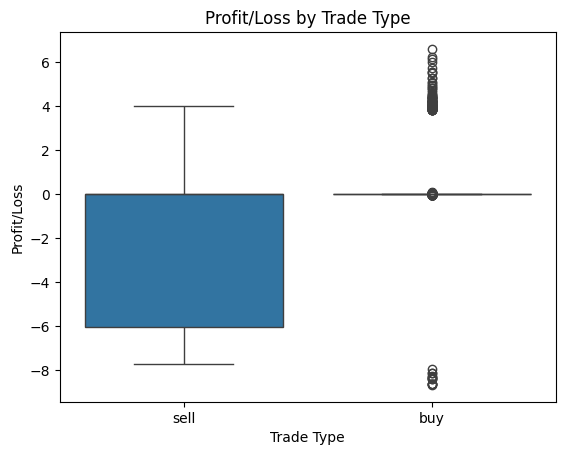

In [8]:
# Box Plot: Profit/Loss by Trade Type
sns.boxplot(x='trade_type', y='profit_loss', data=data)
plt.title('Profit/Loss by Trade Type')
plt.xlabel('Trade Type')
plt.ylabel('Profit/Loss')
plt.show()

In [18]:
data['percentage_profit_loss'] = (data['profit_loss'] / (data['entry_price'] * data['volume'])) * 100

In [20]:
data.head()

,id,profile_id,entry_price,exit_price,volume,trade_type,profit_loss,percentage_profit_loss
0,2,1,1.3600,1.3586,10.0,sell,0.014,0.102941
1,3,1,1.3057,1.3109,10.0,buy,0.052,0.398254
2,4,1,1.3600,1.3592,10.0,sell,0.008,0.058824
3,1156,1,189.8680,190.2500,0.0,buy,0.000,NaN
4,1152,1,1.3090,1.3122,0.0,buy,0.000,NaN


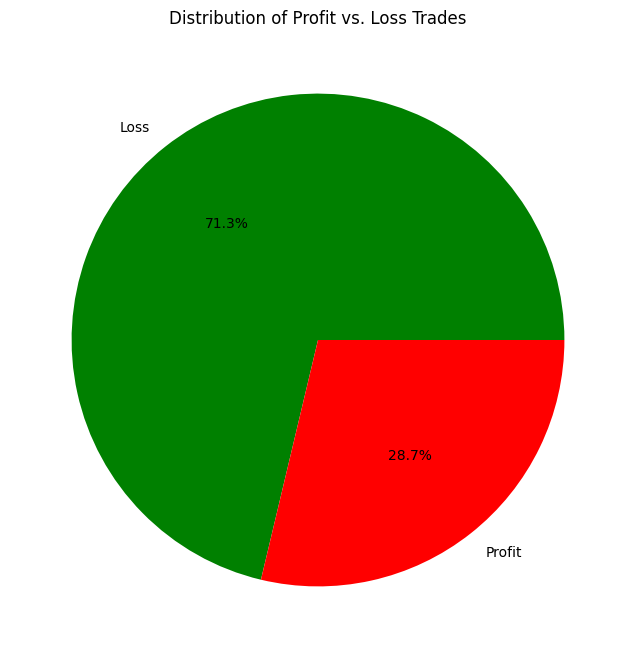

In [22]:
# Classify trades as profit or loss
data['profit_loss_class'] = data['percentage_profit_loss'].apply(lambda x: 'Profit' if x > 0 else 'Loss')

# Count the number of trades in each class
profit_loss_counts = data['profit_loss_class'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(profit_loss_counts, labels=profit_loss_counts.index, autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Distribution of Profit vs. Loss Trades')
plt.show()

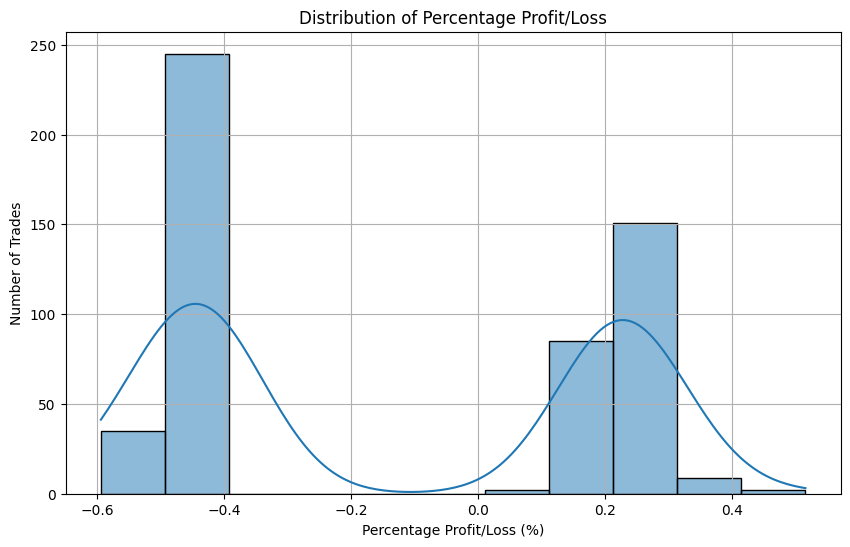

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(data['percentage_profit_loss'], kde=True)
plt.title('Distribution of Percentage Profit/Loss')
plt.xlabel('Percentage Profit/Loss (%)')
plt.ylabel('Number of Trades')
plt.grid(True)
plt.show()